# 16 · Fourier analysis: diagnosing a machine from its vibration

**Problem.** An accelerometer on a pump bearing records vibration velocity at 2048 samples per second.
The shaft turns at 1480 rpm. Is the bearing healthy? In the time signal everything is mixed together
with noise; the **frequency spectrum** separates the contributions: shaft rotation, its harmonics, and -
if present - a bearing-defect frequency. The record is in `pump_vibration.csv` (synthetic, so that we
can check the analysis against what was put into it).

**What you will learn**

- compute a DFT from its definition and understand how the FFT speeds it up
- read an amplitude spectrum to identify machine faults
- explain leakage, windowing, frequency resolution and aliasing
- filter a signal in the frequency domain

**Before you start:** notebook 00; complex exponentials $e^{i\theta} = \cos\theta + i\sin\theta$  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import fourier

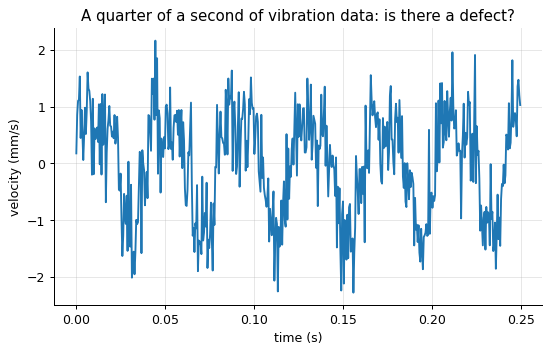

In [2]:
from engmath import datasets
data = np.loadtxt(datasets.path("pump_vibration.csv"), delimiter=",", skiprows=1)
t, signal = data[:, 0], data[:, 1]                    # time (s), vibration velocity (mm/s)
fs = 1 / (t[1] - t[0])                                # sampling rate from the time column: 2048 Hz
duration = t.size / fs
f_shaft = 1480 / 60                                   # shaft speed 1480 rpm = 24.67 Hz
plt.plot(t[:512], signal[:512]); plt.xlabel("time (s)"); plt.ylabel("velocity (mm/s)")
plt.title("A quarter of a second of vibration data: is there a defect?"); plt.show()

## The discrete Fourier transform
The DFT writes $N$ samples as a sum of sinusoids at the frequencies $f_k = k\,f_s/N$:
$$X_k = \sum_{n=0}^{N-1} x_n\,e^{-2\pi i k n/N}.$$
Computed from the definition this costs $N^2$ operations. The **fast Fourier transform** (FFT) splits the
sum into even and odd samples recursively and needs only about $N\log_2 N$:

In [3]:
import time
for N in (256, 1024, 4096):
    x = signal[:N]
    t0 = time.perf_counter(); Xd = fourier.dft(x); td = time.perf_counter() - t0
    t0 = time.perf_counter(); Xf = fourier.fft(x); tf = time.perf_counter() - t0
    t0 = time.perf_counter(); Xn = np.fft.fft(x); tn = time.perf_counter() - t0
    print(f"N = {N:5d}: DFT {td*1e3:8.1f} ms, our FFT {tf*1e3:6.1f} ms, numpy {tn*1e3:5.2f} ms; "
          f"max difference {max(np.max(np.abs(Xd - Xn)), np.max(np.abs(Xf - Xn))):.1e}")

N =   256: DFT      4.2 ms, our FFT    1.6 ms, numpy  0.12 ms; max difference 3.8e-12
N =  1024: DFT     43.0 ms, our FFT    6.0 ms, numpy  0.07 ms; max difference 5.6e-11


N =  4096: DFT    723.7 ms, our FFT   24.6 ms, numpy  0.11 ms; max difference 8.7e-10


## Inside the algorithm: the DFT as a matrix, and the FFT butterfly
The DFT is a matrix-vector product with $W_{kn} = e^{-2\pi i kn/N}$. The FFT computes the same product by
splitting the samples into even and odd ones, transforming each half (recursively), and combining the
two halves with the *twiddle factors* $e^{-2\pi i k/N}$:

In [4]:
N = 8
n = np.arange(N)
W = np.exp(-2j * np.pi * np.outer(n, n) / N)            # the DFT matrix
x8 = signal[:N]
print("DFT matrix product matches numpy:", np.allclose(W @ x8, np.fft.fft(x8)))
show_source(fourier.fft)

DFT matrix product matches numpy: True


def fft(x) -> np.ndarray:
    """Recursive radix-2 Cooley-Tukey FFT: split into even and odd samples, transform each half, and
    combine with 'twiddle factors'. O(N log N). N must be a power of two."""
    x = np.asarray(x, complex)
    N = x.size
    if N == 1:
        return x
    if N & (N - 1):
        raise ValueError("This teaching FFT needs a power-of-two length; use numpy.fft for any length.")
    even, odd = fft(x[0::2]), fft(x[1::2])
    twiddle = np.exp(-2j * np.pi * np.arange(N // 2) / N) * odd
    return np.concatenate([even + twiddle, even - twiddle])

## The amplitude spectrum
`fourier.spectrum` returns frequencies and amplitudes scaled so that a sine of amplitude $A$ appears as
a peak of height about $A$.

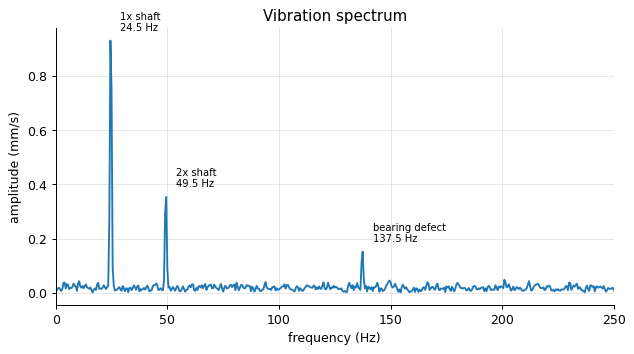

frequency resolution fs/N = 0.50 Hz
defect peak 0.152 mm/s vs median noise level 0.018 mm/s


In [5]:
f, amp = fourier.spectrum(signal, fs, window="hann")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f, amp)
for fr, name in ((f_shaft, "1x shaft"), (2*f_shaft, "2x shaft"), (137.3, "bearing defect")):
    i = np.argmin(abs(f - fr))
    ax.annotate(f"{name}\n{f[i]:.1f} Hz", (f[i], amp[i]), textcoords="offset points", xytext=(8, 8), fontsize=8)
ax.set(xlim=(0, 250), xlabel="frequency (Hz)", ylabel="amplitude (mm/s)", title="Vibration spectrum")
plt.show()
i_def = np.argmin(abs(f - 137.3))
noise_floor = np.median(amp[(f > 60) & (f < 250)])
print(f"frequency resolution fs/N = {fs/t.size:.2f} Hz")
print(f"defect peak {amp[i_def]:.3f} mm/s vs median noise level {noise_floor:.3f} mm/s")

The bearing defect, hidden in the time signal, stands out in the spectrum: the noise is spread over all
frequencies, while a periodic component concentrates in one.

## Leakage and windowing
The shaft frequency (24.67 Hz) falls *between* two frequency bins, which are 0.5 Hz apart. Its energy
then leaks into neighbouring bins. Tapering the record with a **Hann window** reduces the leakage:

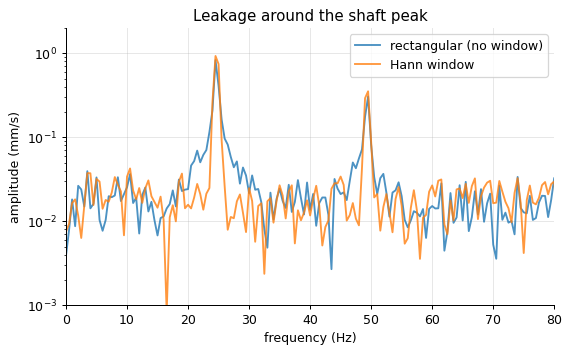

In [6]:
f_r, a_r = fourier.spectrum(signal, fs, window=None)
f_h, a_h = fourier.spectrum(signal, fs, window="hann")
plt.semilogy(f_r, a_r, label="rectangular (no window)", alpha=0.8)
plt.semilogy(f_h, a_h, label="Hann window", alpha=0.8)
plt.xlim(0, 80); plt.ylim(1e-3, 2); plt.xlabel("frequency (Hz)"); plt.ylabel("amplitude (mm/s)")
plt.legend(); plt.title("Leakage around the shaft peak"); plt.show()

## Resolution and aliasing: two ways to be fooled
**Resolution.** Two frequencies closer than about $f_s/N = 1/T_{record}$ cannot be separated - only a
*longer record* helps. **Aliasing.** A frequency above the Nyquist frequency $f_s/2$ is indistinguishable
from a lower one. Sampling the defect vibration at only 200 Hz:

In [7]:
fs_low = 200.0
t_low = np.arange(int(fs_low * duration)) / fs_low
f_al, a_al = fourier.spectrum(np.sin(2*np.pi*137.3*t_low), fs_low)
print(f"a 137.3 Hz sine sampled at {fs_low:.0f} Hz appears at 200 - 137.3 = 62.7 Hz "
      f"(spectrum peak at {f_al[np.argmax(a_al)]:.1f} Hz, the nearest frequency bin)")

a 137.3 Hz sine sampled at 200 Hz appears at 200 - 137.3 = 62.7 Hz (spectrum peak at 62.5 Hz, the nearest frequency bin)


Once sampled, an aliased signal cannot be repaired: data-acquisition systems remove everything above
$f_s/2$ **before** sampling (anti-aliasing filters).

## Filtering in the frequency domain
Keep only a band around the defect frequency and transform back. Because the data file is synthetic, we
know the defect component it contains (0.15 mm/s at 137.3 Hz) and can check the result. How wide should
the band be?

band 130-145 Hz (width 15.0 Hz): RMS error 0.074 mm/s
band 135-140 Hz (width  5.0 Hz): RMS error 0.052 mm/s
band 136-138.5 Hz (width  2.5 Hz): RMS error 0.043 mm/s
band 136.8-137.8 Hz (width  1.0 Hz): RMS error 0.053 mm/s


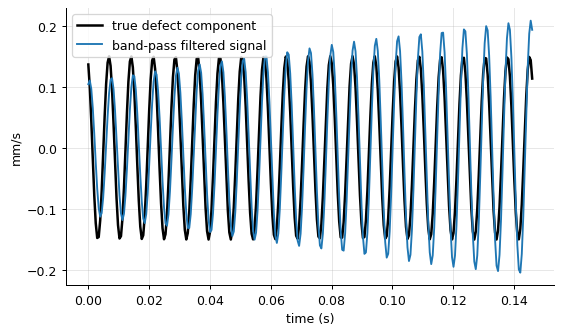

defect RMS 0.106 mm/s, noise RMS 0.5 mm/s


In [8]:
defect_true = 0.15 * np.sin(2*np.pi*137.3*t + 2)
for lo, hi in ((130, 145), (135, 140), (136, 138.5), (136.8, 137.8)):
    est = fourier.fft_filter(signal, fs, low=lo, high=hi)
    print(f"band {lo}-{hi} Hz (width {hi - lo:4.1f} Hz): RMS error {np.sqrt(np.mean((est - defect_true)**2)):.3f} mm/s")
defect_est = fourier.fft_filter(signal, fs, low=136, high=138.5)
plt.plot(t[:300], defect_true[:300], "k", lw=2, label="true defect component")
plt.plot(t[:300], defect_est[:300], label="band-pass filtered signal")
plt.xlabel("time (s)"); plt.ylabel("mm/s"); plt.legend(); plt.show()
print(f"defect RMS {0.15/np.sqrt(2):.3f} mm/s, noise RMS 0.5 mm/s")

A narrower band lets through less noise - but a band that is *too* narrow also cuts off part of the
defect's own energy, which leaks into neighbouring bins because 137.3 Hz is not exactly on a bin. Even
at best, the noise sharing the band remains, so the reconstructed waveform is only approximate. For
**detecting** a fault the spectrum is the better tool; filtering is for separating components whose
frequencies are well apart.

## Exercises
1. Use only the first 0.25 s of data. Can you still separate the shaft peak from its second harmonic?
   What is the frequency resolution now?
2. Zero-pad the 0.25 s record to 2 s (append zeros) and recompute the spectrum. Does that improve the
   *resolution*, or only make the curve smoother?
3. By Parseval's theorem the mean square of the signal equals the sum of squared Fourier amplitudes
   (suitably scaled). Compute the RMS vibration velocity from the spectrum and compare with
   `np.sqrt(np.mean(signal**2))` - the quantity used in vibration-severity standards.
4. **Implement it yourself:** compute the frequency response of a 5-point moving average (notebook 07) by taking the FFT of its kernel zero-padded to 1024 points. Which frequencies does it suppress, and why is it a poor low-pass filter?